In [11]:
import os
import sys

current_dir = os.path.dirname(os.path.abspath(os.getcwd()))
project_root = os.path.abspath(os.path.join(current_dir, '.'))
sys.path.append(project_root)

from src.system.dataset_manager import Dataset_Manager

In [12]:
NAME_DATASET = "dataset_20251001_145915"  # Name of the dataset to be used
dataset = Dataset_Manager()

## 1. Load and preprocess data

In [13]:
dataset.load_images(compute = True, # If True, forces the reloading of images from disk and ignores any cached versions.
    name_dataset = NAME_DATASET,
    test_mode = False, # If True, loads a minimal subset of images for testing purposes (e.g., one mutant, one wild type).
    training = True, # If True, loads data from 'Mutant' and 'WT' directories. If False, loads data from the 'Unclassified' directory
    visualize = False,  # Set to True if you want to visualize the preprocessing results
    validation = False # If True, loads data from the 'validation' directory
)

No cached data found, proceeding with fresh data loading...
Acquiring data...
Processing image: C:\Users\imagerie\Desktop\CribleGenetic\data\Mutant\MutEN6000-0.tif
Processing image: C:\Users\imagerie\Desktop\CribleGenetic\data\Mutant\MutEN6000-22.tif
Processing image: C:\Users\imagerie\Desktop\CribleGenetic\data\Mutant\MutEN6000-64.tif
Processing image: C:\Users\imagerie\Desktop\CribleGenetic\data\Mutant\MutEN6009-1.tif
Processing image: C:\Users\imagerie\Desktop\CribleGenetic\data\Mutant\MutEN6009-16.tif
Processing image: C:\Users\imagerie\Desktop\CribleGenetic\data\Mutant\MutEN6009-28.tif
Processing image: C:\Users\imagerie\Desktop\CribleGenetic\data\Mutant\MutEN6009-3.tif
Processing image: C:\Users\imagerie\Desktop\CribleGenetic\data\Mutant\MutEN6009-45.tif
Skipping coiled worm in C:\Users\imagerie\Desktop\CribleGenetic\data\Mutant\MutEN6009-45.tif
Processing image: C:\Users\imagerie\Desktop\CribleGenetic\data\Mutant\MutEN6009-47.tif
Processing image: C:\Users\imagerie\Desktop\Cribl

## 2. Extract features

In [14]:
dataset.set_features(
    compute = True, # If True, re-computes features from the raw data.
    save_features = True, # If True, saves the computed features to a pickle file.
    name_dataset=NAME_DATASET,
    feature_reduction=False,  # Set to True if you want to apply a feature reduction (PCA)
    verbose=False
)

Computing features...
Extracting features from image 1 of 97
Extracting features from image 2 of 97
Extracting features from image 3 of 97
Extracting features from image 4 of 97
Extracting features from image 5 of 97
Extracting features from image 6 of 97
Extracting features from image 7 of 97
Extracting features from image 8 of 97
Extracting features from image 9 of 97
Extracting features from image 10 of 97
Extracting features from image 11 of 97
Extracting features from image 12 of 97
Extracting features from image 13 of 97
Extracting features from image 14 of 97
Extracting features from image 15 of 97
Extracting features from image 16 of 97
Extracting features from image 17 of 97
Extracting features from image 18 of 97
Extracting features from image 19 of 97
Extracting features from image 20 of 97
Extracting features from image 21 of 97
Extracting features from image 22 of 97
Extracting features from image 23 of 97
Extracting features from image 24 of 97
Extracting features from im

## 3. Compute models

Training classifier...



1 fits failed out of a total of 5.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\imagerie\Desktop\CribleGenetic\.venv\lib\site-packages\sklearn\model_selection\_validation.py", line 729, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\imagerie\Desktop\CribleGenetic\.venv\lib\site-packages\sklearn\base.py", line 1152, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\imagerie\Desktop\CribleGenetic\.venv\lib\site-packages\sklearn\pipeline.py", line 427, in fit
    self._final_estimator.fit(Xt, y, **fit_params_last_step)
  File "c:\Users\imagerie\Desktop\CribleGenetic\src\system\clas

[INFO] Saved 17 selected feature indices to C:\Users\imagerie\Desktop\CribleGenetic\models\selected_features.txt


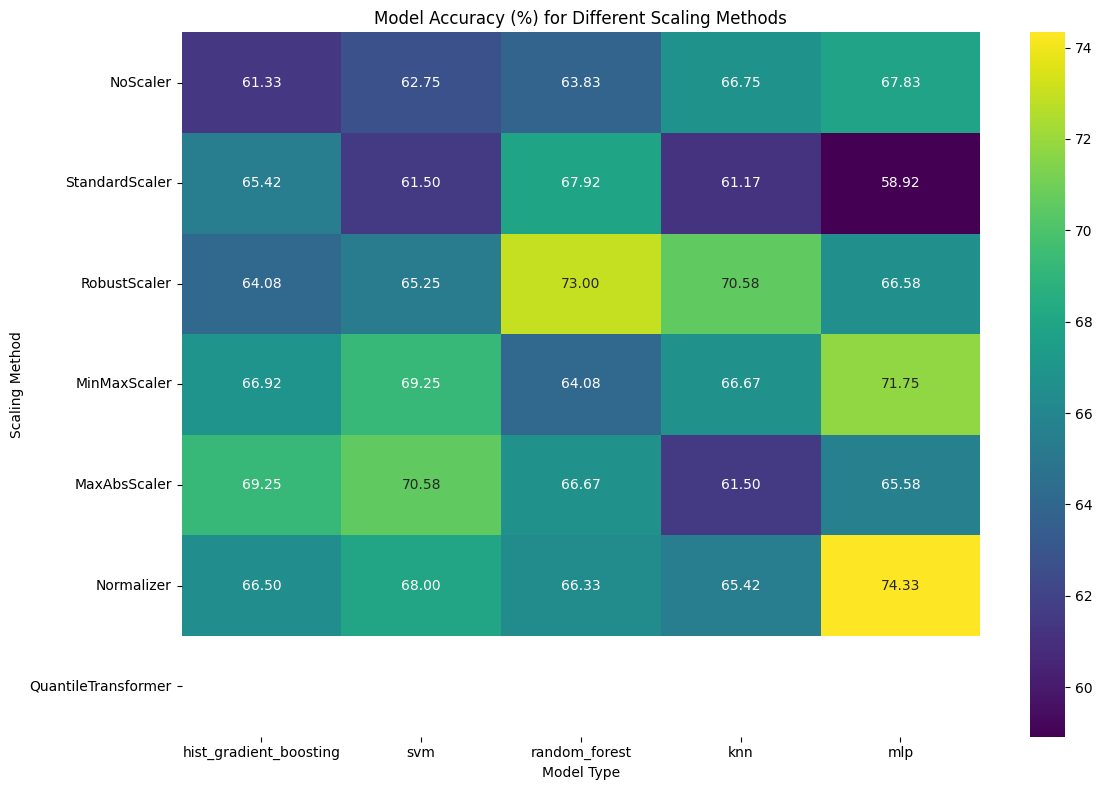

In [15]:
model = dataset.get_model(
    compute=True,
    retrain = True, # If True, forces retraining even if the dataset size hasn't changed.
    model_type = 'classifier', # 'outlier' or 'classifier'
    outlier_type = 'mahalanobis_chi2', # 'elliptic_envelope' or 'mahalanobis_chi2'
    # classifier_type = ['svm'], # ['hist_gradient_boosting', 'svm', 'random_forest', 'knn', 'mlp'] # nothing = everything
    # scaler = ['MaxAbsScaler'], # ['NoScaler','StandardScaler','RobustScaler','MinMaxScaler','MaxAbsScaler','Normalizer','QuantileTransformer'] # nothing = everything
    optimizing = False,
    verbose = True,
    shap_analysis = False,
    feature_selection_method = 'lasso' # 'lasso', 'elasticnet', 'kbest', 'boruta', 'none'
) 

## 4. Prediction

In [16]:
import pandas as pd

# Load validation dataset
dataset_validation = Dataset_Manager()
dataset_validation.load_images(
    compute = True,
    name_dataset = NAME_DATASET,
    validation = True
)
dataset_validation.set_features(
    compute = True,
    name_dataset=NAME_DATASET
)
X, _ = dataset_validation.get_features_selected()

# PREDICTIONS
predictions = model.predict(X)

# Show results
true_labels = dataset_validation.get_y_without_coiled_worm()  # ['Mutant', 'WT', ...]
label_mapping = {'WT': 0, 'Mutant': 1}
true_labels_num = [label_mapping[label] for label in true_labels]
df_comparison = pd.DataFrame({
    'Filename': [item.filename for item in dataset_validation.data if not item.coiled],
    'True label': true_labels,
    'Prediction label': ['Mutant' if p==1 else 'WT' for p in predictions]
})
pd.set_option('display.max_rows', None)
print(df_comparison)

# calculate accuracy
accuracy = (df_comparison['True label'] == df_comparison['Prediction label']).mean()
print(f'Accuracy: {accuracy*100:.2f}%')


Acquiring data...
Processing image: C:\Users\imagerie\Desktop\CribleGenetic\data\validation\MutEN6009-25.tif
Processing image: C:\Users\imagerie\Desktop\CribleGenetic\data\validation\MutEN6009-31.tif
Processing image: C:\Users\imagerie\Desktop\CribleGenetic\data\validation\MutEN6009-42.tif
Processing image: C:\Users\imagerie\Desktop\CribleGenetic\data\validation\MutEN6017-36.tif
Processing image: C:\Users\imagerie\Desktop\CribleGenetic\data\validation\MutEN6017-59.tif
Processing image: C:\Users\imagerie\Desktop\CribleGenetic\data\validation\MutEN6017-61.tif
Processing image: C:\Users\imagerie\Desktop\CribleGenetic\data\validation\MutEN6020-4.tif
Processing image: C:\Users\imagerie\Desktop\CribleGenetic\data\validation\MutEN6020-5.tif
Processing image: C:\Users\imagerie\Desktop\CribleGenetic\data\validation\MutEN6024-2.tif
Processing image: C:\Users\imagerie\Desktop\CribleGenetic\data\validation\MutEN6024-8.tif
Skipping coiled worm in C:\Users\imagerie\Desktop\CribleGenetic\data\validat